# LSTM con atención

### Carga de dependencias y librerias

In [3]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import spacy
import gensim
from spellchecker import SpellChecker
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.nn.utils.rnn import pad_sequence

Carga del Dataset

In [4]:
# Cargar el dataset
data = pd.read_csv(r"C:\Users\DELL\Downloads\LSTM+\jokes.csv")  # CAMBIAR LA RUTA DEL DATASET

### Paso 1: Preparación de Datos
Convertiremos los chistes en secuencias de números (tokens) y utilizaremos embeddings preentrenados.
Esta sección se encarga de preparar un conjunto de datos textuales para ser utilizado en un modelo de aprendizaje profundo. Primero, utiliza el modelo de procesamiento de lenguaje en español de spaCy para tokenizar los textos y un corrector ortográfico para limpiar y normalizar el texto, eliminando caracteres especiales, duplicados y corrigiendo errores. 

Luego, transforma los textos en secuencias de índices utilizando un vocabulario construido a partir del corpus de entrenamiento. Los datos son divididos en conjuntos de entrenamiento y validación, y se crea un Dataset personalizado para manejar textos y etiquetas. 
Finalmente, se implementa una función de colación para alinear las secuencias a la misma longitud mediante relleno y se generan DataLoaders que proporcionan los datos en lotes, listos para ser utilizados en el entrenamiento y evaluación del modelo.

In [5]:
# Cargar el modelo de spaCy para español
nlp = spacy.load("es_core_news_sm")

# Limpieza y corrección ortográfica
def clean_data_with_spellcheck(data):
    # Inicializar corrector ortográfico para español
    spell = SpellChecker(language='es')

    # Seleccionar columnas relevantes
    data = data[['jokeText', 'jokeHasHumor', 'jokeRate']]

    # Manejar valores nulos
    data = data.dropna(subset=['jokeText', 'jokeHasHumor', 'jokeRate'])

    # Convertir columnas a tipos adecuados
    data['jokeHasHumor'] = data['jokeHasHumor'].astype(int)  # Para clasificación binaria
    data['jokeRate'] = data['jokeRate'].astype(int)          # Para clasificación multiclase

    # Remover duplicados
    data = data.drop_duplicates(subset=['jokeText'])

    # Normalizar el texto
    data['jokeText'] = data['jokeText'].str.lower()                # Convertir a minúsculas
    data['jokeText'] = data['jokeText'].str.replace(r'\s+', ' ', regex=True)  # Remover espacios extras
    data['jokeText'] = data['jokeText'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)  # Remover caracteres especiales

    # Corregir errores ortográficos
    def correct_spelling(text):
        words = text.split()
        corrected_words = [
            spell.correction(word) if spell.correction(word) is not None else word for word in words
        ]
        return ' '.join(corrected_words)

    data['jokeText'] = data['jokeText'].apply(correct_spelling)

    return data

# Limpieza de los datos
data = clean_data_with_spellcheck(data)

# Dividir en conjuntos de entrenamiento y validación
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

# Tokenizador con spaCy
def spacy_tokenizer(text):
    return [token.text for token in nlp(text)]

# Crear vocabulario
def yield_tokens(data_iter):
    for text in data_iter['jokeText']:
        yield spacy_tokenizer(text)

vocab = build_vocab_from_iterator(yield_tokens(train_data), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

# Convertir texto a índices
def text_pipeline(text):
    return [vocab[token] for token in spacy_tokenizer(text)]

# Dataset personalizado
class JokeDataset(Dataset):
    def __init__(self, data, target_col):
        self.data = data
        self.target_col = target_col

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = text_pipeline(self.data.iloc[idx]['jokeText'])
        label = self.data.iloc[idx][self.target_col]
        return torch.tensor(text, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Definir la función de colación personalizada
def collate_fn(batch):
    texts, labels = zip(*batch)  # Desempacar las tuplas en textos y etiquetas
    texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)  # Rellenar secuencias
    labels = torch.tensor(labels)  # Convertir etiquetas en tensor
    return texts_padded, labels

# Crear DataLoaders con la función de colación personalizada
train_dataset = JokeDataset(train_data, 'jokeHasHumor')
val_dataset = JokeDataset(val_data, 'jokeHasHumor')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

Guardar los datos del preprocesamiento a un .csv como medida de punto de control futuro

In [6]:
# Exportar datos preprocesados a un archivo CSV
processed_data_path = "datos_preprocesados.csv"  # Especificar el nombre del archivo

# Guardar datos preprocesados
data.to_csv(processed_data_path, index=False)

print(f"Datos preprocesados exportados exitosamente a {processed_data_path}")

Datos preprocesados exportados exitosamente a datos_preprocesados.csv


Con la preparación de datos del dataset, ahora se procede a verificar la distribución grafica de los datos.

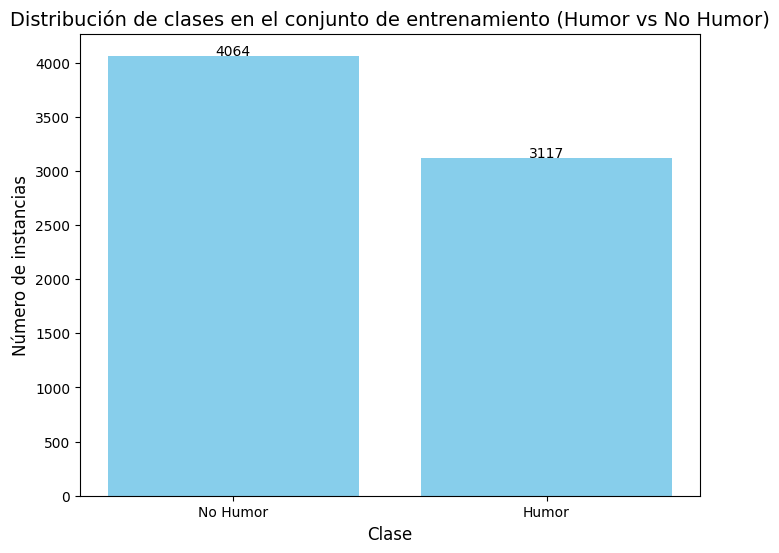

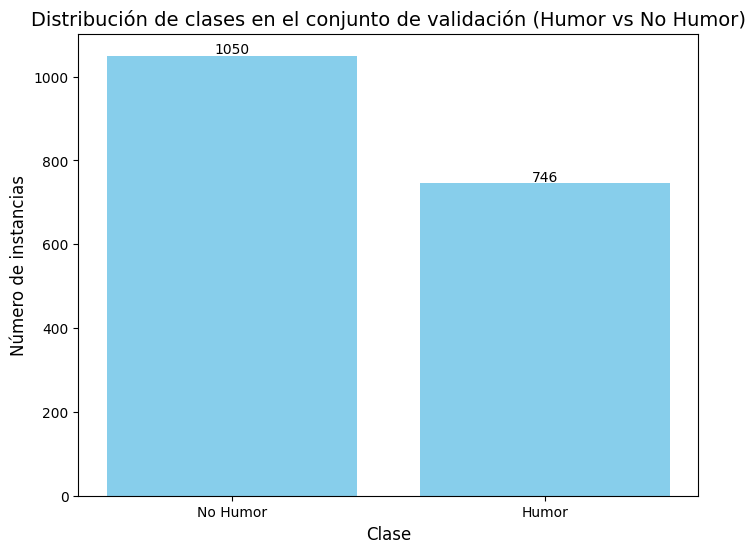

In [7]:
def plot_binary_distribution(data, title):
    # Contar las clases y asignar etiquetas
    class_counts = data['jokeHasHumor'].value_counts()
    labels = ["No Humor", "Humor"]  # Etiquetas personalizadas
    counts = [class_counts[0], class_counts[1]]
    
    # Crear la gráfica de barras
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, counts, color='skyblue')
    plt.xlabel("Clase", fontsize=12)
    plt.ylabel("Número de instancias", fontsize=12)
    plt.title(title, fontsize=14)
    
    # Etiquetas de los valores sobre las barras
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(bar.get_height()), ha='center', fontsize=10)
    
    plt.show()

# Graficar la distribución binaria en los conjuntos de entrenamiento y validación
plot_binary_distribution(train_data, "Distribución de clases en el conjunto de entrenamiento (Humor vs No Humor)")
plot_binary_distribution(val_data, "Distribución de clases en el conjunto de validación (Humor vs No Humor)")

Aqui se verifica la distribución de datos del dataset, en el conjunto de datos multiclase

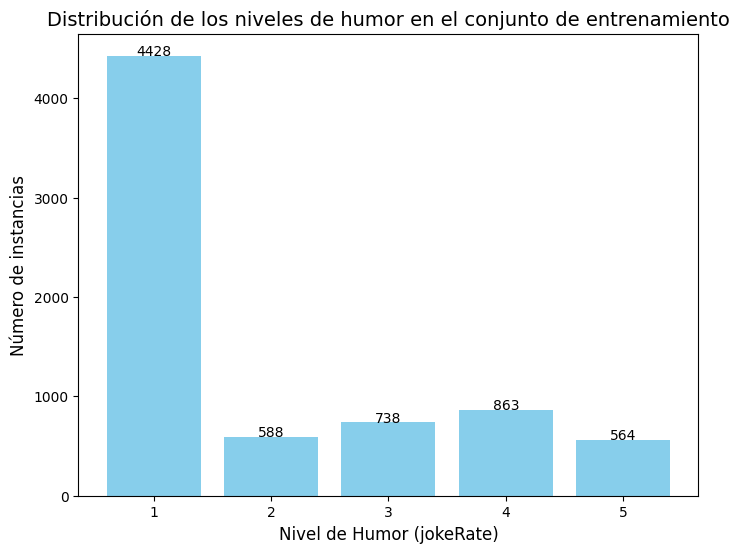

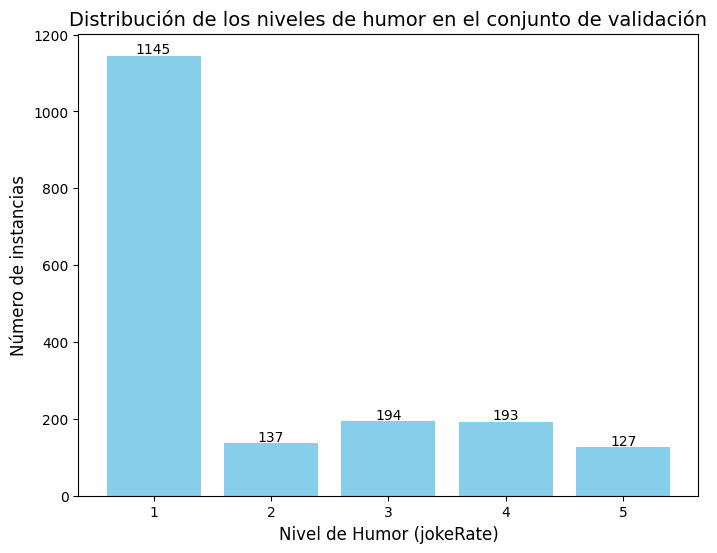

In [8]:
def plot_jokeRate_distribution(data, title):
    jokeRate_counts = data['jokeRate'].value_counts().sort_index()
    plt.figure(figsize=(8, 6))
    bars = plt.bar(jokeRate_counts.index, jokeRate_counts.values, color='skyblue')
    plt.xlabel("Nivel de Humor (jokeRate)", fontsize=12)
    plt.ylabel("Número de instancias", fontsize=12)
    plt.title(title, fontsize=14)
    plt.xticks(jokeRate_counts.index, fontsize=10)
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(bar.get_height()), ha='center', fontsize=10)
    plt.show()

# Graficar la distribución en los conjuntos de entrenamiento y validación
plot_jokeRate_distribution(train_data, "Distribución de los niveles de humor en el conjunto de entrenamiento")
plot_jokeRate_distribution(val_data, "Distribución de los niveles de humor en el conjunto de validación")

Se procede a correlacionar los datos procesados, con embeddings preentrenaos de Word2Vec. En esta sección, se cargan embeddings preentrenados en español desde el preprocesamiento de datos anterior, creando una matriz de embeddings para representar palabras del vocabulario único extraído de los datos de entrenamiento, y prepara DataLoaders para manejar el flujo de datos hacia un modelo de aprendizaje profundo. 

Primero, se define una función para leer los embeddings desde el archivo y almacenarlos en un diccionario. Luego, se genera una matriz de embeddings donde cada palabra del vocabulario se mapea a su vector correspondiente, o a un vector aleatorio si no está presente en los embeddings preentrenados. Finalmente, se implementa un Dataset personalizado que convierte textos en índices basados en el vocabulario, y una función de colación que alinea las secuencias a una longitud común mediante relleno. 
Los DataLoaders generados permiten iterar sobre los datos en lotes durante el entrenamiento y la evaluación del modelo.

In [9]:
# Cargar los embeddings preentrenados en español desde archivo de texto
def load_word2vec_txt(path):
    embeddings_index = {}
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i == 0:  # Ignorar la primera línea si contiene metadatos
                continue
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = vector
    return embeddings_index

# Ruta al archivo de embeddings
embedding_path = r"C:\Users\DELL\Downloads\LSTM+\SBW-vectors-300-min5.txt"  # Ruta de los embeddings preentrenados
word2vec_model = load_word2vec_txt(embedding_path)

# Crear la matriz de embeddings
embedding_dim = len(next(iter(word2vec_model.values())))
vocab = set(train_data['jokeText'].str.split().explode().unique())  # Extraer vocabulario único de los textos
embedding_matrix = torch.zeros((len(vocab), embedding_dim))
word_to_index = {word: idx for idx, word in enumerate(vocab)}

for word, idx in word_to_index.items():
    if word in word2vec_model:
        embedding_matrix[idx] = torch.tensor(word2vec_model[word])
    else:
        embedding_matrix[idx] = torch.randn(embedding_dim)  # Vector aleatorio si no está en Word2Vec

print("Matriz de embeddings creada correctamente.")

# 2. Preparar DataLoaders
def text_to_indices(text, word_to_index):
    return [word_to_index.get(word, 0) for word in text.split()]

class JokeDataset(Dataset):
    def __init__(self, data, target_col):
        self.texts = data['jokeText']
        self.labels = data[target_col]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_indices = text_to_indices(self.texts.iloc[idx], word_to_index)
        label = self.labels.iloc[idx]
        return torch.tensor(text_indices, dtype=torch.long), torch.tensor(label, dtype=torch.float)

# Crear DataLoaders
def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence([torch.tensor(text) for text in texts], batch_first=True, padding_value=0)
    labels = torch.tensor(labels)
    return texts_padded, labels

train_dataset = JokeDataset(train_data, 'jokeHasHumor')
val_dataset = JokeDataset(val_data, 'jokeHasHumor')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

print("DataLoaders preparados correctamente con los embeddings preentrenados.")

Matriz de embeddings creada correctamente.
DataLoaders preparados correctamente con los embeddings preentrenados.


### Paso 2: Definición del Modelo
Implementaremos una arquitectura que combine LSTM con un mecanismo de atención. Para ello, este código define un modelo de red neuronal basado en LSTM con atención y dropout para la clasificación binaria, entrenándolo con diferentes tasas de aprendizaje para ajustar los embeddings preentrenados y las demás capas del modelo. 
El modelo incluye una capa de embeddings inicializada con vectores preentrenados, una capa LSTM para capturar dependencias secuenciales, un mecanismo de atención para enfocar partes relevantes de la secuencia, y una capa fully-connected para generar la salida final. 

Durante el entrenamiento, las tasas de aprendizaje diferenciadas permiten un ajuste gradual (fine-tuning) de los embeddings mientras las demás capas se entrenan con mayor libertad. 
Además, se utiliza dropout para prevenir sobreajuste, y se evalúan métricas como pérdida y precisión en los conjuntos de entrenamiento y validación. El entrenamiento se realiza en múltiples épocas utilizando lotes de datos, con optimización a través del algoritmo Adam y cálculo de la pérdida binaria con BCEWithLogitsLoss

In [31]:
class LSTMAttentionModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix, dropout_prob=0.5):
        super(LSTMAttentionModel, self).__init__()
        # Inicializar la capa de embeddings con los pesos preentrenados
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False  # Permitir ajuste (fine-tuning) de embeddings
        )
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.attention = nn.Linear(hidden_dim, 1)  # Capa para calcular pesos de atención
        self.dropout = nn.Dropout(dropout_prob)  # Capa de dropout con probabilidad configurable
        self.fc = nn.Linear(hidden_dim, output_dim)  # Capa fully-connected

    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)  # (batch_size, seq_length, embedding_dim)

        # LSTM
        lstm_out, _ = self.lstm(embedded)  # (batch_size, seq_length, hidden_dim)
        lstm_out = self.dropout(lstm_out)  # Aplicar dropout a la salida de LSTM

        # Atención
        attention_weights = torch.softmax(self.attention(lstm_out), dim=1)  # (batch_size, seq_length, 1)
        attention_weights = attention_weights.permute(0, 2, 1)  # (batch_size, 1, seq_length)

        # Contexto
        context_vector = torch.bmm(attention_weights, lstm_out)  # (batch_size, 1, hidden_dim)
        context_vector = context_vector.squeeze(1)  # (batch_size, hidden_dim)
        context_vector = self.dropout(context_vector)  # Aplicar dropout al vector de contexto

        # Clasificación
        output = self.fc(context_vector)  # (batch_size, output_dim)

        return output

# Crear el modelo
vocab_size = len(vocab)  
embedding_dim = embedding_matrix.shape[1]  # Debe coincidir con los embeddings preentrenados
hidden_dim = 128
output_dim = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Crear el modelo con dropout
dropout_prob = 0.3  # Probabilidad de dropout
model = LSTMAttentionModel(vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix, dropout_prob).to(device)

# Definir diferentes tasas de aprendizaje
learning_rate_embeddings = 1e-4  # Tasa de aprendizaje más baja para embeddings
learning_rate_rest = 1e-3  # Tasa de aprendizaje estándar para el resto del modelo

# Crear grupos de parámetros
optimizer = optim.Adam([
    {'params': model.embedding.parameters(), 'lr': learning_rate_embeddings},  # Capa de embeddings
    {'params': model.lstm.parameters()},  # LSTM
    {'params': model.attention.parameters()},  # Atención
    {'params': model.fc.parameters()},  # Fully-connected
], lr=learning_rate_rest, weight_decay=1e-5)  # Tasa de aprendizaje para capas no especificadas

# Función de entrenamiento ajustada con tasas de aprendizaje personalizadas
def train_model_with_custom_lr(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    
    # Ajustar la tasa de aprendizaje dinámicamente según la pérdida de validación
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for batch in train_loader:
            texts, labels = batch
            texts, labels = texts.to(device), labels.to(device).float()

            optimizer.zero_grad()
            predictions = model(texts).squeeze(1)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        print(f"Epoch {epoch+1}, Training Loss: {epoch_loss / len(train_loader)}")

        # Evaluación en validación
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for batch in val_loader:
                texts, labels = batch
                texts, labels = texts.to(device), labels.to(device).float()

                predictions = model(texts).squeeze(1)
                val_loss += criterion(predictions, labels).item()
                correct += ((torch.sigmoid(predictions) > 0.5) == labels).sum().item()
                
        scheduler.step(val_loss)  # Actualizar la tasa de aprendizaje según la pérdida de validación

        print(f"Validation Loss: {val_loss / len(val_loader)}, Accuracy: {correct / len(val_loader.dataset)}")

# Función de pérdida
criterion = nn.BCEWithLogitsLoss()

# Entrenar el modelo
train_model_with_custom_lr(model, train_loader, val_loader, criterion, optimizer, epochs=10)

C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\192608523.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(embedding_matrix, dtype=torch.float32),
C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\2285359625.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores


Epoch 1, Training Loss: 0.6857917004161411
Validation Loss: 0.6795079467589396, Accuracy: 0.5846325167037862
Epoch 2, Training Loss: 0.6850279291470845
Validation Loss: 0.6789193352063497, Accuracy: 0.5846325167037862
Epoch 3, Training Loss: 0.6845576718118456
Validation Loss: 0.6789510312833285, Accuracy: 0.5846325167037862
Epoch 4, Training Loss: 0.6844046195348104
Validation Loss: 0.678657729374735, Accuracy: 0.5846325167037862
Epoch 5, Training Loss: 0.6827004708184137
Validation Loss: 0.6834145428841574, Accuracy: 0.5762806236080178
Epoch 6, Training Loss: 0.6748251655366686
Validation Loss: 0.6816746446124294, Accuracy: 0.5400890868596881
Epoch 7, Training Loss: 0.6411898024876912
Validation Loss: 0.7456901324422736, Accuracy: 0.5428730512249443
Epoch 8, Training Loss: 0.5849402249521679
Epoch 00008: reducing learning rate of group 0 to 5.0000e-05.
Epoch 00008: reducing learning rate of group 1 to 5.0000e-04.
Epoch 00008: reducing learning rate of group 2 to 5.0000e-04.
Epoch 000

### Paso 3: Entrenamiento
Entrenaremos el modelo para la tarea binaria (humorístico/no humorístico). Esta sección implementa un pipeline de entrenamiento para un modelo de clasificación binaria con Early Stopping. Primero, define una función personalizada de colación (collate_fn) para procesar y rellenar secuencias de longitud variable, lo que asegura que los textos y las etiquetas estén alineados correctamente al ser cargados en los DataLoaders. Luego, inicializa el modelo LSTMAttentionModel con embeddings preentrenados, una LSTM con atención y Dropout, configurando también un optimizador Adam con diferentes tasas de aprendizaje para las capas del modelo. 

Durante el entrenamiento, el modelo ajusta sus parámetros minimizando la pérdida de entropía cruzada binaria. Se evalúa en cada época usando un conjunto de validación para calcular la pérdida y precisión. La lógica de Early Stopping detiene el entrenamiento si no hay mejoras en la pérdida de validación durante un número consecutivo de épocas definido por patience. Si se activa, se restaura automáticamente el estado del modelo con el mejor desempeño en validación. Finalmente, se ejecuta el entrenamiento completo utilizando estos elementos.

In [33]:
# Colación personalizada
def collate_fn(batch):
    texts, labels = zip(*batch)  # Desempacar las tuplas en textos y etiquetas
    texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)  # Rellenar secuencias
    labels = torch.tensor(labels)  # Convertir etiquetas en tensor
    return texts_padded, labels

# Calcular métricas
def calculate_metrics(predictions, labels):
    preds = (torch.sigmoid(predictions) > 0.5).cpu().numpy()  # Convertir predicciones a binario
    labels = labels.cpu().numpy()
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    accuracy = accuracy_score(labels, preds)
    return precision, recall, f1, accuracy

# Crear DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)

# Hiperparámetros
embedding_dim = embedding_matrix.shape[1]  # Dimensión de los embeddings preentrenados
hidden_dim = 128
output_dim = 1
vocab_size = len(vocab)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Inicializar modelo
model = LSTMAttentionModel(vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix).to(device)

# Optimizer con tasas de aprendizaje personalizadas
learning_rate_embeddings = 1e-4  # Tasa de aprendizaje más baja para embeddings
learning_rate_rest = 1e-3  # Tasa de aprendizaje estándar para el resto del modelo

optimizer = optim.Adam([
    {'params': model.embedding.parameters(), 'lr': learning_rate_embeddings},  # Embeddings
    {'params': model.lstm.parameters()},  # LSTM
    {'params': model.attention.parameters()},  # Atención
    {'params': model.fc.parameters()},  # Fully-connected
], lr=learning_rate_rest, weight_decay=1e-5)

# Función de entrenamiento con Early Stopping
def train_model_with_early_stopping_and_metrics(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=5):
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None  # Guardar el mejor modelo

    # Inicializar historial
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_precision': [],
        'val_precision': [],
        'train_recall': [],
        'val_recall': [],
        'train_f1': [],
        'val_f1': [],
        'train_accuracy': [],
        'val_accuracy': []
    }
    
    # Ajustar la tasa de aprendizaje dinámicamente según la pérdida de validación
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        all_train_predictions = []
        all_train_labels = []

        for batch in train_loader:
            texts, labels = batch
            texts, labels = texts.to(device), labels.to(device).float()

            optimizer.zero_grad()
            predictions = model(texts).squeeze(1)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            all_train_predictions.append(predictions)
            all_train_labels.append(labels)

        # Métricas de entrenamiento
        all_train_predictions = torch.cat(all_train_predictions)
        all_train_labels = torch.cat(all_train_labels)
        train_precision, train_recall, train_f1, train_accuracy = calculate_metrics(all_train_predictions, all_train_labels)

        # Actualizar historial de entrenamiento
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['train_precision'].append(train_precision)
        history['train_recall'].append(train_recall)
        history['train_f1'].append(train_f1)
        history['train_accuracy'].append(train_accuracy)

        # Validación
        model.eval()
        val_loss = 0
        all_val_predictions = []
        all_val_labels = []

        with torch.no_grad():
            for batch in val_loader:
                texts, labels = batch
                texts, labels = texts.to(device), labels.to(device).float()
                predictions = model(texts).squeeze(1)
                val_loss += criterion(predictions, labels).item()
                all_val_predictions.append(predictions)
                all_val_labels.append(labels)
        
        scheduler.step(val_loss)  # Actualizar la tasa de aprendizaje según la pérdida de validación

        # Métricas de validación
        all_val_predictions = torch.cat(all_val_predictions)
        all_val_labels = torch.cat(all_val_labels)
        val_precision, val_recall, val_f1, val_accuracy = calculate_metrics(all_val_predictions, all_val_labels)

        # Actualizar historial de validación
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['val_f1'].append(val_f1)
        history['val_accuracy'].append(val_accuracy)

        print(f"Epoch {epoch+1}:")
        print(f"  Training Loss: {history['train_loss'][-1]:.4f}, Accuracy: {history['train_accuracy'][-1]:.4f}")
        print(f"  Validation Loss: {history['val_loss'][-1]:.4f}, "
              f"Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-Score: {val_f1:.4f}, Accuracy: {val_accuracy:.4f}")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict()  # Guardar el mejor modelo
            print(f"Validation Loss improved to {best_val_loss:.4f}. Saving model...")
        else:
            patience_counter += 1
            print(f"No improvement. Patience counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

    # Restaurar el mejor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Best model restored.")

    return history

# Función de pérdida
criterion = nn.BCEWithLogitsLoss()

# Ejecutar el entrenamiento
history = train_model_with_early_stopping_and_metrics(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=5)

C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\192608523.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(embedding_matrix, dtype=torch.float32),
C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\3139283315.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores
C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\3139283315.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensore

Epoch 1:
  Training Loss: 0.6857, Accuracy: 0.5662
  Validation Loss: 0.6794, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000, Accuracy: 0.5846
Validation Loss improved to 38.7266. Saving model...


C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\3139283315.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\3139283315.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Co

Epoch 2:
  Training Loss: 0.6851, Accuracy: 0.5659
  Validation Loss: 0.6792, Precision: 0.0000, Recall: 0.0000, F1-Score: 0.0000, Accuracy: 0.5846
Validation Loss improved to 38.7164. Saving model...


C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\3139283315.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores


...

Epoch 6:
  Training Loss: 0.6624, Accuracy: 0.6006
  Validation Loss: 0.7071, Precision: 0.4380, Recall: 0.6059, F1-Score: 0.5084, Accuracy: 0.5134
No improvement. Patience counter: 3/5


C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\3139283315.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores
C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\3139283315.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores


Epoch 00007: reducing learning rate of group 0 to 5.0000e-05.
Epoch 00007: reducing learning rate of group 1 to 5.0000e-04.
Epoch 00007: reducing learning rate of group 2 to 5.0000e-04.
Epoch 00007: reducing learning rate of group 3 to 5.0000e-04.
Epoch 7:
  Training Loss: 0.6232, Accuracy: 0.6512
  Validation Loss: 0.7506, Precision: 0.4442, Recall: 0.4960, F1-Score: 0.4687, Accuracy: 0.5329
No improvement. Patience counter: 4/5


C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\3139283315.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores
C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\3139283315.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores


Epoch 8:
  Training Loss: 0.5614, Accuracy: 0.7069
  Validation Loss: 0.7607, Precision: 0.4397, Recall: 0.4598, F1-Score: 0.4495, Accuracy: 0.5323
No improvement. Patience counter: 5/5
Early stopping triggered!
Best model restored.


### Paso 4: Evaluación
Evaluaremos el modelo con métricas como precisión, recall, F1, y exactitud. Esta sección, define un flujo completo de entrenamiento y validación de un modelo, incluyendo el cálculo y registro de métricas clave como precisión, recall, F1-score y exactitud. La función calculate_metrics convierte las predicciones del modelo en valores binarios mediante una función sigmoide y un umbral de 0.5, y calcula las métricas al comparar estas predicciones con las etiquetas reales. 
Durante el entrenamiento, la función train_model_with_metrics_and_plot acumula predicciones y etiquetas en cada época para calcular las métricas de entrenamiento, mientras optimiza los pesos del modelo mediante gradiente descendente. 

Luego, evalúa el modelo en el conjunto de validación, acumulando predicciones y etiquetas para calcular las mismas métricas en validación. 
Los resultados de pérdida y métricas se registran en un historial (history) para cada época, permitiendo comparaciones entre entrenamiento y validación, y proporcionando un resumen detallado de la evolución del modelo.

In [34]:
# Evaluación del modelo restaurado
def evaluate_model(model, data_loader, criterion):
    model.eval()  # Configurar el modelo en modo evaluación
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():  # Deshabilitar gradientes para evaluar
        for texts, labels in data_loader:
            texts, labels = texts.to(device), labels.to(device).float()
            predictions = model(texts).squeeze(1)
            loss = criterion(predictions, labels)
            total_loss += loss.item()
            all_predictions.append(predictions)
            all_labels.append(labels)

    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)
    precision, recall, f1, accuracy = calculate_metrics(all_predictions, all_labels)
    avg_loss = total_loss / len(data_loader)

    print(f"Evaluation Results:")
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, Accuracy: {accuracy:.4f}")

    return avg_loss, precision, recall, f1, accuracy

# Evaluar el modelo restaurado en el conjunto de validación o prueba
val_loss, val_precision, val_recall, val_f1, val_accuracy = evaluate_model(model, val_loader, criterion)

C:\Users\DELL\AppData\Local\Temp\ipykernel_31728\3139283315.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  texts = [torch.tensor(text) for text in texts]  # Convertir textos en tensores


Evaluation Results:
  Loss: 0.7607
  Precision: 0.4397, Recall: 0.4598, F1-Score: 0.4495, Accuracy: 0.5323


### Análisis cuantitativo detallado
Esta sección, realiza dos tareas principales: graficar las métricas de entrenamiento y validación, y mostrar una matriz de confusión normalizada basada en los resultados de validación del modelo. 

La función plot_metrics genera gráficos comparativos entre entrenamiento y validación para pérdida, precisión, recall y F1-score, destacando cómo evolucionan estas métricas a lo largo de las épocas de entrenamiento. Verifica que los datos correspondientes estén disponibles en el historial antes de graficar. La función plot_confusion_matrix, por otro lado, evalúa el modelo en el conjunto de validación, recopila las predicciones y etiquetas verdaderas, calcula una matriz de confusión normalizada y la presenta visualmente con etiquetas 'No Humor' y 'Humor', ayudando a entender el desempeño del modelo en términos de clasificación correcta e incorrecta. 

Finalmente, se entrena el modelo con la función train_model_with_metrics_and_plot y se grafican tanto las métricas como la matriz de confusión para una evaluación exhaustiva del desempeño del modelo.

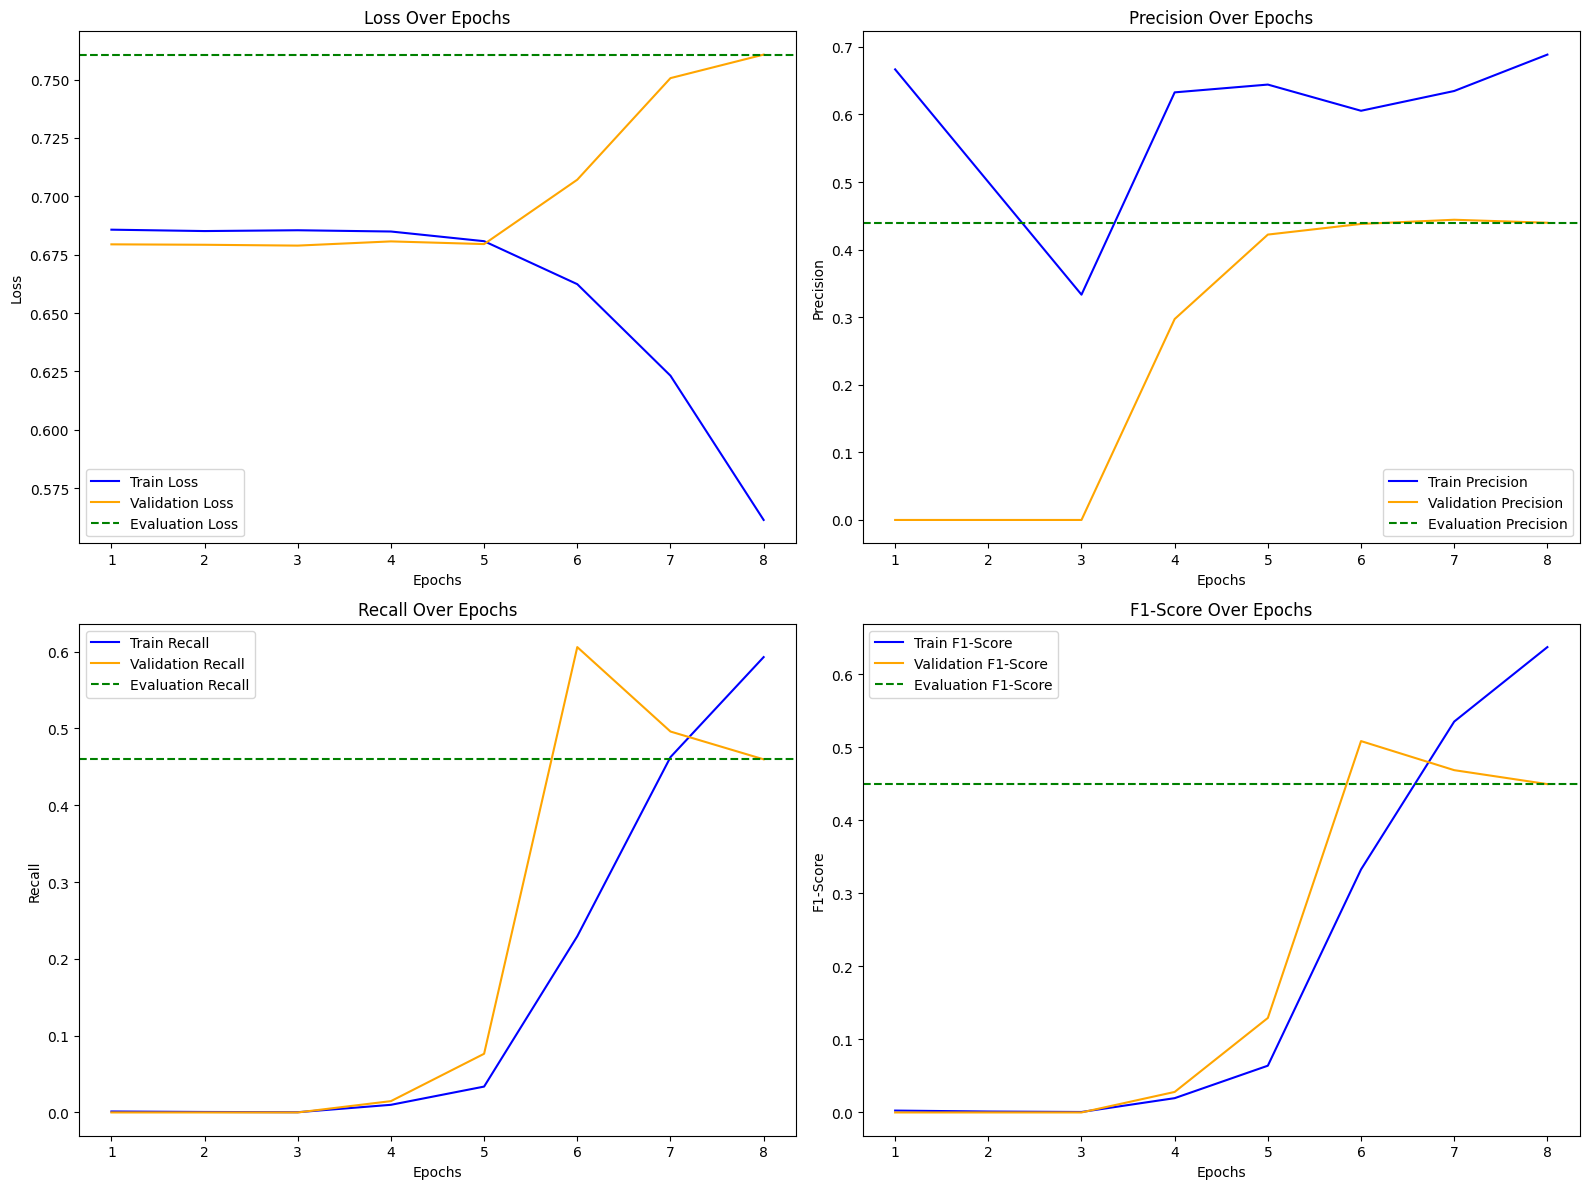

In [35]:
# Función actualizada para graficar métricas con evaluación final
def plot_metrics_with_evaluation(history, evaluation_results):
    epochs = len(history['train_loss'])

    plt.figure(figsize=(16, 12))

    # Pérdida
    plt.subplot(2, 2, 1)
    plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss', color='blue')
    plt.plot(range(1, epochs + 1), history['val_loss'], label='Validation Loss', color='orange')
    plt.axhline(evaluation_results['loss'], color='green', linestyle='--', label='Evaluation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Over Epochs')
    plt.legend()

    # Precisión
    plt.subplot(2, 2, 2)
    plt.plot(range(1, epochs + 1), history['train_precision'], label='Train Precision', color='blue')
    plt.plot(range(1, epochs + 1), history['val_precision'], label='Validation Precision', color='orange')
    plt.axhline(evaluation_results['precision'], color='green', linestyle='--', label='Evaluation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.title('Precision Over Epochs')
    plt.legend()

    # Recall
    plt.subplot(2, 2, 3)
    plt.plot(range(1, epochs + 1), history['train_recall'], label='Train Recall', color='blue')
    plt.plot(range(1, epochs + 1), history['val_recall'], label='Validation Recall', color='orange')
    plt.axhline(evaluation_results['recall'], color='green', linestyle='--', label='Evaluation Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.title('Recall Over Epochs')
    plt.legend()

    # F1-Score
    plt.subplot(2, 2, 4)
    plt.plot(range(1, epochs + 1), history['train_f1'], label='Train F1-Score', color='blue')
    plt.plot(range(1, epochs + 1), history['val_f1'], label='Validation F1-Score', color='orange')
    plt.axhline(evaluation_results['f1'], color='green', linestyle='--', label='Evaluation F1-Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1-Score')
    plt.title('F1-Score Over Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Resultados finales de evaluación
evaluation_results = {
    "loss": val_loss,
    "precision": val_precision,
    "recall": val_recall,
    "f1": val_f1,
    "accuracy": val_accuracy
}

# Graficar las métricas incluyendo los resultados finales de evaluación
plot_metrics_with_evaluation(history, evaluation_results)